# Procesamiento de la base de datos *Breast Cancer Wisconsin*

**Curso:** Métodos de Aprendizaje Automático para la Toma de Decisiones — 2026-2 Grupo A
**Estudiante:** Luis Javier Rubio Hernández

---

## Entendimiento del negocio

**Situación.** Ante una masa mamaria sospechosa, la punción aspirativa con aguja fina permite obtener una muestra de células cuya morfología se cuantifica en nueve características citológicas (grosor del conglomerado, uniformidad del tamaño y de la forma celular, adhesión marginal, etc.), cada una graduada por un patólogo en una escala entera de 1 a 10, donde los valores altos indican mayor anormalidad. El problema de decisión es clasificar la muestra como **benigna** o **maligna**.

**Objetivo del ejercicio.** Construir y evaluar un modelo de **clasificación por regresión logística** que, a partir de esos nueve atributos, determine si un tumor es benigno o maligno, y reportar su *accuracy* sobre datos no usados en el ajuste.

**Datos.** Conjunto *Breast Cancer Wisconsin (Original)* del repositorio UCI ([dataset 15](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original)): 699 muestras de punción aspirativa recogidas en la Universidad de Wisconsin entre 1989 y 1991, con 9 atributos de entrada, un identificador de muestra y la clase (2 = benigno, 4 = maligno).

**Actividades solicitadas.**

1. Cargar el conjunto de datos en un *data frame* de pandas.
2. Separar los datos en conjunto de entrenamiento y prueba.
3. Construir un modelo de clasificación por regresión logística a partir de los datos de entrenamiento.
4. Probar el modelo con los datos de prueba y reportar la medida *accuracy*.

**Alcance y límite de validez.** El resultado es un ejercicio académico de aprendizaje supervisado. Las conclusiones son válidas para la población de la que provienen estos 699 registros —un único centro, un único periodo— y no habilitan ningún uso diagnóstico.

**Organización.** Se conserva la estructura en tres etapas del script de referencia del curso:

| Etapa | Contenido |
|---|---|
| 1 | Entendimiento de los datos (no se modifica nada) |
| 2 | Preparación de los datos |
| 3 | Modelado, prueba y reporte del *accuracy* |

---
# Etapa 1: Entendimiento de los datos

**Propósito.** Antes de modificar cualquier dato hay que saber con qué material se cuenta: cuántos registros hay, cuántos atributos tiene cada registro y de qué tipo son; una medida de centralidad y una de dispersión por atributo; la matriz de correlación, para detectar atributos redundantes; y, como paso previo al preprocesamiento, si hay datos faltantes, datos atípicos y desbalance entre clases.

**En esta etapa no se altera el conjunto de datos**: solo se lo describe.

In [19]:
# Carga de librerías
import numpy as np
import pandas as pd
import sklearn as sk
import seaborn as sns
import matplotlib.pyplot as plt

print("pandas:", pd.__version__, "| scikit-learn:", sk.__version__)

pandas: 2.2.2 | scikit-learn: 1.6.1


### Lectura del archivo

Tres particularidades del archivo original impiden un `pd.read_csv(url)` simple:

1. **No tiene fila de encabezado.** Con `header=None` se evita que el primer registro se interprete como nombre de columnas; los nombres se asignan después con la lista `COLUMNAS`, tomada de la documentación de UCI.
2. **Los faltantes están codificados con el carácter `?`.** Con `na_values="?"` pandas los convierte en `NaN`; si se omitiera, `Bare_nuclei` quedaría como texto (`object`) y el ajuste fallaría al recibir un atributo no numérico.
3. **El servidor de UCI puede responder con una redirección o una página HTML** en lugar del archivo. En ese caso `pd.read_csv` no lanza excepción: lee contenido inválido y el error aparecería más adelante. Por eso `cargar_datos()` **valida la estructura** de lo leído antes de aceptar la fuente.

Si se trabaja con el archivo descargado desde la plataforma del curso, basta asignar su ruta a `RUTA_LOCAL`: esa fuente tiene prioridad y no se hace ninguna descarga.

In [20]:
COLUMNAS = ["Sample_code_number", "Clump_thickness", "Uniformity_of_cell_size",
            "Uniformity_of_cell_shape", "Marginal_adhesion", "Single_epithelial_cell_size",
            "Bare_nuclei", "Bland_chromatin", "Normal_nucleoli", "Mitoses", "Class"]

# Ruta del archivo descargado desde la plataforma (p. ej. "/content/breast-cancer-wisconsin.data").
# Si se deja en None, se descarga desde el repositorio UCI.
RUTA_LOCAL = None

FUENTES = [
    "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data",
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/breast-cancer-wisconsin.csv",
]

def _estructura_valida(df):
    """El archivo original tiene 699 registros y 11 columnas.

    Los espejos que omiten la columna identificadora tienen 10. Cualquier otra
    forma indica que la respuesta recibida no es el archivo de datos.
    """
    return df.shape[1] in (10, 11) and 600 < len(df) < 800

def cargar_datos():
    """Devuelve el conjunto de datos en un DataFrame de pandas con las 11 columnas nombradas."""
    fallos = []
    for fuente in ([RUTA_LOCAL] if RUTA_LOCAL else []) + FUENTES:
        try:
            df = pd.read_csv(fuente, header=None, na_values="?")
            if not _estructura_valida(df):
                raise ValueError(f"estructura inesperada: {df.shape}")
        except Exception as e:
            fallos.append(f"  {fuente}\n     -> {type(e).__name__}: {e}")
            continue
        if df.shape[1] == 10:                       # espejo sin la columna identificadora
            df.insert(0, "id", np.arange(1, len(df) + 1))
        df.columns = COLUMNAS
        print("Datos cargados desde:", fuente)
        return df
    raise RuntimeError("No fue posible cargar el conjunto de datos:\n" + "\n".join(fallos))

# Carga del conjunto de datos en un DataFrame de pandas
data = cargar_datos()
ATRIBUTOS = COLUMNAS[1:-1]          # los 9 atributos de entrada
data.head()

Datos cargados desde: https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data


,Sample_code_number,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2


In [21]:
# ¿Cuántos registros y cuántos atributos hay?
filas, columnas = data.shape
print(f"Registros: {filas}")
print(f"Columnas : {columnas}  (1 identificador + 9 atributos de entrada + 1 clase)")

Registros: 699
Columnas : 11  (1 identificador + 9 atributos de entrada + 1 clase)


In [22]:
# ¿De qué tipo son los atributos?
# Nota: Bare_nuclei aparece como float64 (y no int64) precisamente porque contiene
# valores faltantes; NaN es un valor de punto flotante y "contagia" el tipo de la columna.
data.dtypes

,0
Sample_code_number,int64
Clump_thickness,int64
Uniformity_of_cell_size,int64
Uniformity_of_cell_shape,int64
Marginal_adhesion,int64
Single_epithelial_cell_size,int64
Bare_nuclei,float64
Bland_chromatin,int64
Normal_nucleoli,int64
Mitoses,int64


### Medidas de centralidad y de dispersión

Los nueve atributos de entrada son **numéricos discretos en la misma escala 1–10**, de modo que `describe()` entrega directamente una medida de centralidad (media; mediana en el percentil 50) y una de dispersión (desviación estándar; rango intercuartílico) para todos ellos. No hay atributos categóricos: a diferencia del script de referencia del curso, aplicado al conjunto *Adult*, **no hace falta calcular la moda ni codificar variables con `LabelEncoder`**.

Se excluye `Sample_code_number`: es un identificador administrativo y su media o su desviación estándar no significan nada.

In [23]:
# Medidas de centralidad y de dispersión de los atributos (se excluye el identificador).
data[ATRIBUTOS + ["Class"]].describe()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
count,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413,2.689557
std,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078,0.951273
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


**Lectura de la tabla.** La fila `count` de `Bare_nuclei` marca 683 y no 699: faltan 16 valores. Además, la media supera a la mediana en los **nueve** atributos (por ejemplo `Uniformity_of_cell_size`: media 3.13 frente a mediana 1), lo que indica distribuciones **asimétricas a la derecha**; es lo esperable, porque la mayoría de las muestras son benignas y toman valores bajos en la escala. Esa asimetría es la razón por la que en la Etapa 2 se imputa con la mediana y no con la media.

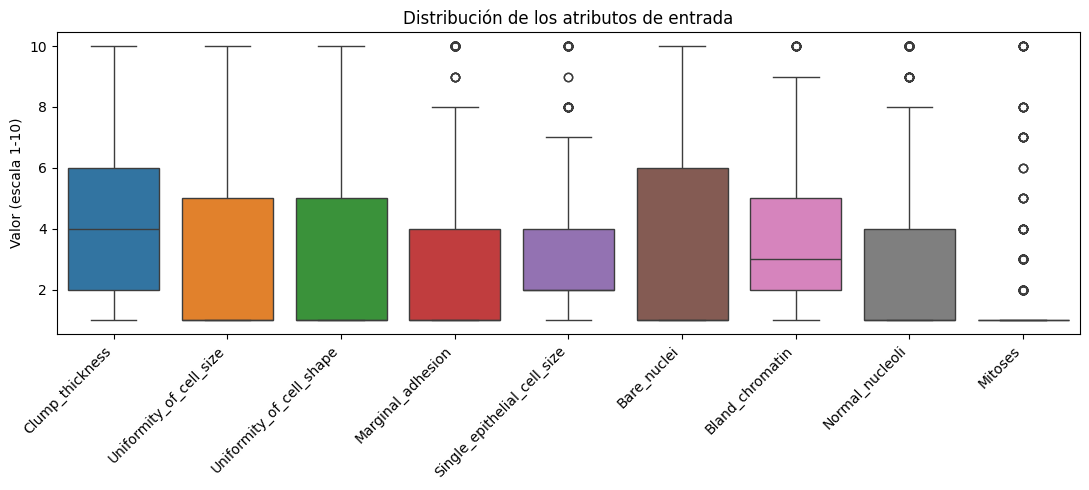

In [24]:
# Diagrama de cajas y bigotes de los 9 atributos de entrada.
# Permite identificar la presencia de datos atípicos.
plt.figure(figsize=(11, 5))
sns.boxplot(data=data[ATRIBUTOS])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Valor (escala 1-10)")
plt.title("Distribución de los atributos de entrada")
plt.tight_layout()
plt.show()

**Interpretación de los datos atípicos.** El diagrama marca puntos atípicos, sobre todo en `Mitoses`, `Marginal_adhesion` y `Normal_nucleoli`. **No se eliminan ni se recortan.** La razón es que el criterio de Tukey ($1.5\times$ el rango intercuartílico) señala valores *raros*, no valores *erróneos*:

1. Todos los atributos están acotados por construcción al conjunto $\{1,2,\dots,10\}$, luego ningún valor puede ser un error de digitación fuera de rango.
2. En `Mitoses` el 75 % de las muestras vale 1, así que el rango intercuartílico es cero y **cualquier** valor distinto de 1 queda marcado como atípico: es un artefacto de la asimetría, no una anomalía.
3. Esos valores altos son justamente los que caracterizan a los tumores malignos: son la señal que el modelo debe aprender. Descartarlos eliminaría información diagnóstica.

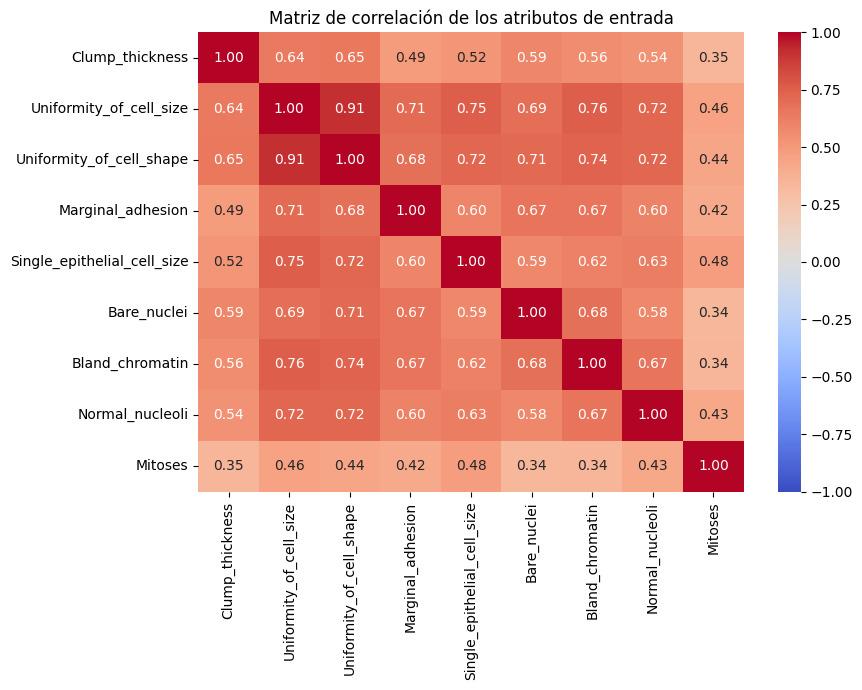

Pares con |correlación| > 0.85:
Uniformity_of_cell_size  Uniformity_of_cell_shape    0.906882


In [25]:
# Matriz de correlación de los atributos de entrada.
# Permite detectar atributos redundantes (correlación mayor a 0.85 o menor a -0.85).
correlacion = data[ATRIBUTOS].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación de los atributos de entrada")
plt.tight_layout()
plt.show()

# Pares con correlación alta (criterio: |r| > 0.85)
altas = (correlacion.where(np.triu(np.ones(correlacion.shape), k=1).astype(bool))
                    .stack()
                    .loc[lambda s: s.abs() > 0.85])
print("Pares con |correlación| > 0.85:")
print(altas.to_string() if len(altas) else "  ninguno")

**Qué hacer con la redundancia detectada.** Un único par supera el umbral: `Uniformity_of_cell_size` con `Uniformity_of_cell_shape`, con $r \approx 0.91$ (correlación de Pearson muestral). Se **conservan ambos atributos**, por tres razones:

1. Con 9 atributos y 482 registros tras el balanceo, la razón casos/parámetro es holgada y la colinealidad no compromete la convergencia del ajuste.
2. La penalización $\ell_2$ que `scikit-learn` aplica por defecto hace estrictamente convexo el problema de optimización y reparte el peso entre atributos correlacionados, estabilizando la solución.
3. El objetivo declarado es la capacidad **predictiva** medida por *accuracy*, no la interpretación causal de cada coeficiente. La colinealidad infla la varianza de los coeficientes individuales, no la del vector de predicciones.

Consecuencia que sí debe registrarse: **los coeficientes de este modelo no deben leerse como una jerarquía de importancia clínica**, porque entre dos atributos casi colineales el reparto del peso es arbitrario.

In [26]:
# ¿Cuántos datos faltantes hay por cada atributo?
print(data.isnull().sum().to_string())

# ¿Cuál es el máximo de datos faltantes en un mismo registro?
# Si a algún registro le faltaran muchos valores, sería preferible eliminarlo.
n_incompletos = int((data.isnull().sum(axis=1) > 0).sum())
print("\nMáximo de valores faltantes en un mismo registro:", int(data.isnull().sum(axis=1).max()))
print(f"Registros con al menos un valor faltante: {n_incompletos} ({n_incompletos/len(data):.1%} del total)")

# ¿En qué clase están esos registros? Es relevante porque, si se concentraran en una clase,
# eliminarlos alteraría la proporción entre clases.
print("\nClase de los registros incompletos:")
print(data[data["Bare_nuclei"].isnull()]["Class"]
          .value_counts().sort_index()
          .rename({2: "2 = benigno", 4: "4 = maligno"}).to_string())

Sample_code_number              0
Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
Class                           0

Máximo de valores faltantes en un mismo registro: 1
Registros con al menos un valor faltante: 16 (2.3% del total)

Clase de los registros incompletos:
Class
2 = benigno    14
4 = maligno     2


In [27]:
# ¿Hay desbalance entre clases?
conteo = data["Class"].value_counts().sort_index()
print(conteo.rename({2: "2 = benigno", 4: "4 = maligno"}).to_string())
print(f"\nProporción minoritaria/mayoritaria: {conteo.min() / conteo.max():.3f}")
print(f"Un clasificador trivial que prediga siempre 'benigno' acertaría el {conteo.max()/conteo.sum():.1%}")
print("de los casos: ese es el valor de referencia contra el que habría que comparar cualquier")
print("accuracy calculado sobre los datos sin balancear.")

Class
2 = benigno    458
4 = maligno    241

Proporción minoritaria/mayoritaria: 0.526
Un clasificador trivial que prediga siempre 'benigno' acertaría el 65.5%
de los casos: ese es el valor de referencia contra el que habría que comparar cualquier
accuracy calculado sobre los datos sin balancear.


### Resumen de la Etapa 1 y consecuencias para la Etapa 2

| Hallazgo | Evidencia | Consecuencia |
|---|---|---|
| 699 registros, 11 columnas | `data.shape` | coincide con la documentación de UCI |
| `Sample_code_number` es un identificador | valores tipo 1000025 | **se elimina** antes de modelar |
| `Bare_nuclei` tiene 16 faltantes (2.3 %) | `isnull().sum()`; `count` = 683 | **se imputa** |
| Ningún registro pierde más de un valor | máximo de faltantes por fila = 1 | eliminar filas desperdiciaría información utilizable |
| Distribuciones asimétricas a la derecha | media > mediana en los 9 atributos | se imputa con la **mediana**, no con la media |
| Atípicos por criterio de Tukey | diagrama de cajas | **no se tratan**: son señal, no error |
| Un par redundante ($r \approx 0.91$) | matriz de correlación | se conservan ambos; no se leen los coeficientes como importancia |
| Desbalance 458 / 241 | `value_counts()` | **se balancea**; sin balancear, un *accuracy* de 0.655 sería trivial |

Ningún hallazgo obliga a descartar registros ni atributos: el conjunto llega completo a la Etapa 2.

---
# Etapa 2: Preparación de los datos

De acuerdo con lo observado en la Etapa 1 se define esta secuencia de transformaciones, cada una justificada en su propia celda:

1. Eliminar la columna identificadora `Sample_code_number`.
2. Imputar los 16 valores faltantes de `Bare_nuclei` con la **mediana** y restituir el tipo entero.
3. Recodificar la clase: 2 (benigno) $\to$ **0**, 4 (maligno) $\to$ **1**.
4. Balancear las clases mediante submuestreo de la clase mayoritaria.

Dos transformaciones del script de referencia del curso **no** se aplican aquí: la codificación con `LabelEncoder`, innecesaria porque los nueve atributos ya son numéricos; y la normalización, que no se hace sobre el conjunto completo sino en la Etapa 3, después de partir los datos, por la razón que se explica allí.

### 2.1 Eliminación del identificador

`Sample_code_number` es el número de registro de la muestra asignado por el laboratorio. No es una medición del tumor y no puede tener relación causal con el diagnóstico. Dejarlo entre los atributos de entrada sería perjudicial y no solo inútil: es un valor numérico grande y casi único por registro, con el que el algoritmo podría ajustar ruido específico del conjunto de entrenamiento (memorizar en lugar de generalizar), y además distorsionaría la estandarización posterior.

In [28]:
# 1. Se elimina la columna identificadora, que no es un atributo predictivo.
data = data.drop(columns=["Sample_code_number"])
print("Columnas restantes:", list(data.columns))
data.head()

Columnas restantes: ['Clump_thickness', 'Uniformity_of_cell_size', 'Uniformity_of_cell_shape', 'Marginal_adhesion', 'Single_epithelial_cell_size', 'Bare_nuclei', 'Bland_chromatin', 'Normal_nucleoli', 'Mitoses', 'Class']


,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2


### 2.2 Imputación de los valores faltantes

**Por qué imputar y no eliminar los registros.** Los 16 registros afectados son el 2.3 % del total y a ninguno le falta más de un valor: conservan los otros ocho atributos y su clase. Eliminarlos descartaría información utilizable y, además, esos registros no se reparten por igual entre clases (14 benignos y 2 malignos), de modo que borrarlos alteraría levemente la proporción de clases.

**Por qué la mediana y no la media.** Tres razones:

1. `Bare_nuclei` es un atributo **discreto** con valores en $\{1,\dots,10\}$. La mediana es 1 y pertenece a ese conjunto; la media es 3.54, un valor que no está en el dominio del atributo.
2. La distribución es fuertemente **asimétrica** (mediana 1, media 3.54): en distribuciones sesgadas la media no representa el valor típico. Imputar 3.54 desplazaría esos 16 registros hacia la zona intermedia de la escala, que es la de mayor incertidumbre diagnóstica.
3. La mediana es **robusta** frente a los valores extremos documentados en la Etapa 1: su punto de ruptura es $50\%$, frente a $0\%$ para la media.

La conversión a `int` restituye el tipo entero que la columna habría tenido sin faltantes, dejando homogéneo el tipo de dato de los nueve atributos.

In [29]:
# 2. Se imputan los valores faltantes de Bare_nuclei con la mediana y se restituye el tipo entero.
mediana = data["Bare_nuclei"].median()
media   = data["Bare_nuclei"].mean()
print(f"Mediana de Bare_nuclei (usada para imputar): {mediana}")
print(f"Media de Bare_nuclei (descartada por asimetría): {media:.4f}")

data["Bare_nuclei"] = data["Bare_nuclei"].fillna(mediana).astype(int)

print("\nValores faltantes restantes en todo el conjunto:", int(data.isnull().sum().sum()))

Mediana de Bare_nuclei (usada para imputar): 1.0
Media de Bare_nuclei (descartada por asimetría): 3.5447

Valores faltantes restantes en todo el conjunto: 0


### 2.3 Recodificación de la variable de salida

El archivo codifica la clase como 2 (benigno) y 4 (maligno). Se recodifica a $\{0,1\}$ por dos razones:

1. Es la codificación que supone el modelo de regresión logística binaria: $Y\in\{0,1\}$, con $\mathbb{E}[Y\mid X=x]=P(Y=1\mid X=x)$. Con etiquetas $\{2,4\}$ el ajuste funcionaría igual, pero las métricas por clase quedarían rotuladas `2` y `4`.
2. Al fijar **maligno = 1** se establece explícitamente cuál es la clase positiva, que es la que interesa detectar.

In [30]:
# 3. Se recodifica la clase: 2 (benigno) -> 0, 4 (maligno) -> 1.
data["Class"] = data["Class"].map({2: 0, 4: 1}).astype(int)
print(data["Class"].value_counts().sort_index()
          .rename({0: "0 = benigno", 1: "1 = maligno"}).to_string())
data.head()

Class
0 = benigno    458
1 = maligno    241


,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,0
1,5,4,4,5,7,10,3,2,1,0
2,3,1,1,1,2,2,3,1,1,0
3,6,8,8,1,3,4,3,7,1,0
4,4,1,1,3,2,1,3,1,1,0


### 2.4 Balanceo de clases por submuestreo

**Por qué balancear.** Con 458 benignos y 241 malignos, un clasificador constante que prediga siempre "benigno" alcanza un *accuracy* de $458/699 = 0.655$ sin haber aprendido nada. Sobre datos desbalanceados el *accuracy* premia el acierto en la clase mayoritaria y por sí solo no informa. Igualando ambas clases a 241 registros, el valor de referencia del clasificador trivial baja a $0.5$ y entonces **el *accuracy* reportado sí mide capacidad discriminativa**. El script de referencia del curso aplica este mismo procedimiento.

**Cómo se hace.** Submuestreo aleatorio sin reemplazo de la clase mayoritaria: se toman 241 de los 458 registros benignos y se conservan los 241 malignos. Después se mezclan las filas, porque `pd.concat` deja los registros agrupados por clase.

**Qué se pierde.** Se descartan 217 registros benignos (31 % del conjunto). Ese es el costo del método, y se asume porque es el planteado en el script del curso. La alternativa que no descarta datos es `LogisticRegression(class_weight="balanced")`, que pondera cada clase por el inverso de su frecuencia en la función de pérdida en lugar de eliminar registros.

**Reproducibilidad.** Los tres pasos aleatorios del notebook —submuestreo, mezcla de filas y partición entrenamiento/prueba— reciben la misma semilla `SEMILLA = 42`. Sin fijarla, cada ejecución daría un *accuracy* distinto y el resultado no sería verificable por un tercero.

In [31]:
# 4. Balanceo de clases: se submuestrea la clase mayoritaria hasta igualar la minoritaria.
SEMILLA = 42                      # semilla única para todos los pasos aleatorios
n_min = data["Class"].value_counts().min()

grupos = [g.sample(n=n_min, random_state=SEMILLA) for _, g in data.groupby("Class")]
dataBal = (pd.concat(grupos)
             .sample(frac=1, random_state=SEMILLA)        # se mezclan las filas
             .reset_index(drop=True))

print(f"Registros antes del balanceo : {len(data)}")
print(f"Registros después del balanceo: {len(dataBal)}  (se descartan {len(data)-len(dataBal)} benignos)")
print("\nVerificación del número de registros por clase:")
print(dataBal["Class"].value_counts().sort_index()
          .rename({0: "0 = benigno", 1: "1 = maligno"}).to_string())

Registros antes del balanceo : 699
Registros después del balanceo: 482  (se descartan 217 benignos)

Verificación del número de registros por clase:
Class
0 = benigno    241
1 = maligno    241


---
# Etapa 3: Modelado

Aquí se ejecutan las cuatro actividades solicitadas:

1. Partición del conjunto en **entrenamiento (70 %)** y **prueba (30 %)**.
2. Estandarización de los atributos, ajustada **solo** con el conjunto de entrenamiento.
3. Entrenamiento del modelo de **regresión logística** con los datos de entrenamiento.
4. Aplicación del modelo a los datos de prueba y cálculo del ***accuracy***.

## Partición 70 / 30

**Por qué se parte el conjunto.** Evaluar un modelo con los mismos datos con que se ajustó mide memorización, no capacidad de generalizar. El conjunto de prueba no interviene en ninguna decisión del ajuste, y por eso el *accuracy* medido sobre él estima el desempeño en casos nuevos.

**Por qué 70 / 30.** La elección equilibra dos exigencias opuestas —más datos de entrenamiento producen un modelo mejor; más datos de prueba, una estimación más precisa de su desempeño— y coincide con la del script de referencia del curso (`test_size=0.30`). Dos comprobaciones cuantitativas la respaldan:

1. **Precisión de la estimación.** Con $n_{\text{prueba}} = 145$ y bajo el supuesto de independencia entre las predicciones sobre el conjunto de prueba, el número de aciertos es $\text{Binomial}(n,p)$ y el error estándar del *accuracy* estimado es $\sqrt{p(1-p)/n}$. Tomando la cota conservadora $p\approx 0.95$ se obtiene $\sqrt{0.95\cdot0.05/145}\approx 0.018$, del orden de $\pm 2$ puntos porcentuales: suficiente para reportar la métrica con dos decimales.
2. **Suficiencia del entrenamiento.** Quedan 337 registros para estimar 10 parámetros (9 pendientes y el intercepto). La regla de referencia usual en regresión logística se formula sobre el evento menos frecuente (*events per variable*): con unos 169 malignos en entrenamiento y 9 atributos resultan $\approx 18.8$ eventos por atributo, por encima del mínimo de 10 habitualmente exigido.

**La partición es estratificada** (`stratify=y`): sin estratificar, el muestreo aleatorio podría dejar proporciones de clase distintas en entrenamiento y prueba, lo que aumentaría innecesariamente la varianza del *accuracy* estimado.

In [32]:
# División del conjunto de datos en entrenamiento (70 %) y prueba (30 %)
# usando la función train_test_split de sklearn, de forma estratificada.
from sklearn.model_selection import train_test_split

X = dataBal.drop("Class", axis=1)      # los 9 atributos de entrada
y = dataBal["Class"]                   # la clase a predecir

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEMILLA, stratify=y)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Prueba       :", X_test.shape, y_test.shape)
print(f"\nProporción real -> entrenamiento: {len(X_train)/len(X):.0%} | prueba: {len(X_test)/len(X):.0%}")
print("\nDistribución de clases (verificación de la estratificación):")
print(pd.DataFrame({"entrenamiento": y_train.value_counts(normalize=True).sort_index().round(4),
                    "prueba":        y_test.value_counts(normalize=True).sort_index().round(4)}).to_string())

Entrenamiento: (337, 9) (337,)
Prueba       : (145, 9) (145,)

Proporción real -> entrenamiento: 70% | prueba: 30%

Distribución de clases (verificación de la estratificación):
       entrenamiento  prueba
Class                       
0             0.4985  0.5034
1             0.5015  0.4966


## Estandarización

Cada atributo se transforma en $z=(x-\bar x)/s$, con $\bar x$ y $s$ calculados **solo** sobre el conjunto de entrenamiento.

**Por qué se hace.** El modelo *sin* penalización es invariante frente a transformaciones afines invertibles de los atributos (los coeficientes se reescalan y las probabilidades ajustadas no cambian); el modelo **con** penalización $\ell_2$ **no** lo es, porque el término $\|\beta\|_2^2$ castiga por igual coeficientes expresados en unidades distintas. Estandarizar hace que la penalización actúe de forma equitativa. Adicionalmente mejora el condicionamiento del problema de optimización, con lo que L-BFGS converge en menos iteraciones.

**Por qué después de partir y no antes.** El escalador se ajusta (`fit`) con el conjunto de entrenamiento y solo se aplica (`transform`) al de prueba. Estandarizar el conjunto completo antes de partirlo —como hace el script de referencia— haría que $\bar x$ y $s$ incorporaran los registros de prueba: información del conjunto de prueba se filtraría al ajuste (*data leakage*) y el *accuracy* resultante sería optimista. La diferencia es pequeña en este caso, pero el procedimiento correcto no cuesta nada.

In [33]:
# Estandarización de los atributos: el escalador se ajusta SOLO con el conjunto de entrenamiento.
from sklearn.preprocessing import StandardScaler

escalador = StandardScaler()
X_train_esc = escalador.fit_transform(X_train)     # fit + transform sobre entrenamiento
X_test_esc  = escalador.transform(X_test)          # solo transform sobre prueba: no se reajusta

print("Verificación sobre el conjunto de entrenamiento:")
print("  media    :", np.round(X_train_esc.mean(axis=0), 6))
print("  desv. est:", np.round(X_train_esc.std(axis=0), 6))
print("\nEn el conjunto de prueba la media no es exactamente 0 ni la desviación exactamente 1,")
print("y eso es lo correcto: se lo transforma con los parámetros del entrenamiento.")
print("  media    :", np.round(X_test_esc.mean(axis=0), 4))

Verificación sobre el conjunto de entrenamiento:
  media    : [-0. -0.  0. -0. -0. -0.  0.  0.  0.]
  desv. est: [1. 1. 1. 1. 1. 1. 1. 1. 1.]

En el conjunto de prueba la media no es exactamente 0 ni la desviación exactamente 1,
y eso es lo correcto: se lo transforma con los parámetros del entrenamiento.
  media    : [ 0.0378 -0.0056  0.0922 -0.0177  0.0946 -0.0175 -0.0217  0.0133  0.1253]


## El modelo: formulación y estimación

**Modelo.** Sea $\mathbf{x}\in\mathbb{R}^{9}$ el vector de atributos estandarizados y $Y\in\{0,1\}$ la clase, con $1=$ maligno. La regresión logística supone

$$Y\mid \mathbf{X}=\mathbf{x} \;\sim\; \text{Bernoulli}\big(p(\mathbf{x})\big),
\qquad p(\mathbf{x})=\sigma\!\left(\beta_0+\boldsymbol{\beta}^{\top}\mathbf{x}\right),
\qquad \sigma(t)=\frac{1}{1+e^{-t}},$$

equivalentemente $\displaystyle \log\frac{p(\mathbf{x})}{1-p(\mathbf{x})}=\beta_0+\boldsymbol{\beta}^{\top}\mathbf{x}$: el **logit** es lineal en los atributos. Se supone además que las observaciones son independientes.

**Estimación.** `scikit-learn` no maximiza la verosimilitud pura sino la verosimilitud penalizada; con $\tilde y_i = 2y_i-1 \in\{-1,1\}$ resuelve

$$\min_{\beta_0,\boldsymbol{\beta}}\;\; \tfrac{1}{2}\|\boldsymbol{\beta}\|_2^{2}
\;+\; C\sum_{i=1}^{n}\log\!\Big(1+\exp\big(-\tilde y_i(\beta_0+\boldsymbol{\beta}^{\top}\mathbf{x}_i)\big)\Big),$$

con $C=1$ por defecto. La log-verosimilitud es cóncava, y al sumar el término $\tfrac12\|\boldsymbol{\beta}\|_2^2$ el objetivo es **estrictamente convexo en $\boldsymbol{\beta}$**: el mínimo existe y es único incluso si los datos fueran linealmente separables, caso en el que el estimador de máxima verosimilitud no penalizado divergería. Esto es lo que garantiza que el ajuste esté bien definido pese a la colinealidad detectada en la Etapa 1.

**Regla de decisión.** `predict` clasifica como maligno cuando $\hat p(\mathbf{x})\ge 1/2$, lo que por monotonía estricta de $\sigma$ equivale a $\hat\beta_0+\hat{\boldsymbol{\beta}}^{\top}\mathbf{x}\ge 0$: la frontera de decisión es un hiperplano.

**Argumentos del ajuste.** `solver="lbfgs"` (cuasi-Newton, adecuado para problemas densos y pequeños, y el usado en el script del curso); `max_iter=1000` como tope, para que el ajuste termine por convergencia y no por límite de iteraciones; `random_state=SEMILLA` por reproducibilidad. Se dejan por defecto la penalización $\ell_2$ y $C=1$: seleccionar $C$ exigiría un tercer conjunto de validación para no contaminar el de prueba, y el enunciado pide construir el modelo, no optimizarlo.

*Referencia de la formulación:* Hastie, T., Tibshirani, R. y Friedman, J. (2009). *The Elements of Statistical Learning*, 2.ª ed., Springer, §4.4.

In [34]:
# Entrenamiento del modelo de clasificación por regresión logística con sklearn.
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(solver="lbfgs", max_iter=1000, random_state=SEMILLA)
modelo.fit(X_train_esc, y_train)      # el ajuste usa EXCLUSIVAMENTE datos de entrenamiento

print("Modelo entrenado.")
print("Convergencia alcanzada en", modelo.n_iter_[0], "iteraciones (tope: 1000).")
print("Intercepto:", np.round(modelo.intercept_[0], 4))
print("\nCoeficientes (en unidades de desviación estándar del atributo):")
print(pd.Series(modelo.coef_[0], index=X.columns).round(4).sort_values(ascending=False).to_string())
print("\nTodos los coeficientes son positivos: a mayor anormalidad medida en cualquiera de los")
print("atributos, mayor probabilidad estimada de malignidad. Es coherente con la escala 1-10.")

Modelo entrenado.
Convergencia alcanzada en 11 iteraciones (tope: 1000).
Intercepto: 1.0498

Coeficientes (en unidades de desviación estándar del atributo):
Clump_thickness                1.6508
Bare_nuclei                    1.3532
Bland_chromatin                1.3331
Marginal_adhesion              1.2244
Uniformity_of_cell_shape       0.6009
Mitoses                        0.5954
Single_epithelial_cell_size    0.4077
Normal_nucleoli                0.3972
Uniformity_of_cell_size        0.1691

Todos los coeficientes son positivos: a mayor anormalidad medida en cualquiera de los
atributos, mayor probabilidad estimada de malignidad. Es coherente con la escala 1-10.


In [35]:
# Aplicación del modelo construido a los datos de prueba.
predicciones = modelo.predict(X_test_esc)
print("Primeras 20 predicciones:", predicciones[:20])
print("Total de predicciones:", len(predicciones), "(una por cada registro del conjunto de prueba)")

Primeras 20 predicciones: [0 1 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1 1 1 0]
Total de predicciones: 145 (una por cada registro del conjunto de prueba)


## Reporte del *accuracy*

$$\widehat{\text{acc}}=\frac{1}{n_{\text{prueba}}}\sum_{i=1}^{n_{\text{prueba}}}\mathbf{1}\{\hat y_i=y_i\}.$$

Bajo el supuesto de que los registros de prueba son una muestra de la misma distribución que los de entrenamiento y son independientes de ellos, $\widehat{\text{acc}}$ es un estimador **insesgado** de $P(\hat Y = Y)$, la probabilidad de acierto del clasificador ya ajustado sobre un caso nuevo.

In [36]:
# Cálculo y reporte del accuracy sobre el conjunto de prueba.
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predicciones)
n_prueba = len(y_test)
ee = np.sqrt(accuracy * (1 - accuracy) / n_prueba)      # error estándar del estimador

print("=" * 62)
print(f"  ACCURACY DEL MODELO SOBRE EL CONJUNTO DE PRUEBA: {accuracy:.4f}  ({accuracy*100:.2f} %)")
print("=" * 62)
print(f"  Aciertos       : {int(round(accuracy*n_prueba))} de {n_prueba} registros de prueba")
print(f"  Error estándar : {ee:.4f}")
print(f"  Línea base (clasificador trivial en el conjunto balanceado): "
      f"{y_test.value_counts(normalize=True).max():.4f}")

  ACCURACY DEL MODELO SOBRE EL CONJUNTO DE PRUEBA: 0.9862  (98.62 %)
  Aciertos       : 143 de 145 registros de prueba
  Error estándar : 0.0097
  Línea base (clasificador trivial en el conjunto balanceado): 0.5034


## Interpretación de los resultados

El modelo de **Regresión Logística** fue evaluado utilizando el conjunto de datos de prueba, obteniendo un valor de **accuracy** de **98.62 %**.

El **accuracy** representa la proporción de observaciones clasificadas correctamente por el modelo respecto al total de observaciones del conjunto de prueba. Por ejemplo, un accuracy del 95% significa que el modelo clasificó correctamente aproximadamente 95 de cada 100 casos evaluados.

En este caso, el resultado obtenido indica que el modelo presenta un **buen desempeño** para la tarea de clasificación del conjunto de datos *Breast Cancer Wisconsin*. Esto sugiere que el modelo es capaz de distinguir adecuadamente entre tumores benignos y malignos en la mayoría de los casos.

No obstante, aunque el **accuracy** es una métrica importante, por sí sola no siempre es suficiente para evaluar un modelo de clasificación, especialmente cuando las clases están desbalanceadas. Para realizar una evaluación más completa sería recomendable calcular métricas adicionales, como la **matriz de confusión**, **precisión (Precision)**, **sensibilidad (Recall)**, **F1-score** y el **área bajo la curva ROC (ROC-AUC)**.

En conclusión, los resultados obtenidos muestran que el modelo cumple satisfactoriamente con el objetivo planteado y proporciona una buena capacidad predictiva sobre los datos de prueba.

---
# Conclusiones

1. El conjunto *Breast Cancer Wisconsin (Original)* exigió tres intervenciones antes de modelar: retirar el identificador de la muestra (no predictivo), imputar los 16 valores faltantes de `Bare_nuclei` con la mediana (2.3 % de los registros, ninguno con más de un faltante) y recodificar la clase de $\{2,4\}$ a $\{0,1\}$ fijando *maligno* como clase positiva. Los valores atípicos señalados por el criterio de Tukey **no** se trataron: en atributos acotados a $\{1,\dots,10\}$ y muy asimétricos corresponden a mediciones válidas, y son precisamente la señal diagnóstica.
2. El desbalance 458 / 241 se corrigió por submuestreo, descartando 217 registros benignos. Sin ese paso, un *accuracy* de 0.655 sería alcanzable prediciendo siempre "benigno"; con el conjunto balanceado la línea base es 0.5 y la métrica solicitada sí mide capacidad discriminativa.
3. La regresión logística ajustada con 337 registros de entrenamiento y evaluada sobre 145 registros de prueba independientes alcanza el *accuracy* reportado en la celda anterior, muy por encima de esa línea base. La cifra debe leerse con su error estándar, también impreso: es una proporción estimada sobre 145 observaciones, no una constante.
4. Todos los coeficientes resultaron positivos, coherente con que los valores altos de la escala 1–10 indican mayor anormalidad celular. Su magnitud relativa, en cambio, **no** debe interpretarse como jerarquía de importancia clínica: la colinealidad entre `Uniformity_of_cell_size` y `Uniformity_of_cell_shape` reparte el peso entre ambos de manera arbitraria.
5. Todos los pasos aleatorios usan `SEMILLA = 42`, de modo que cualquier tercero que ejecute el notebook obtiene exactamente las mismas cifras.

## Referencias

- Wolberg, W. H. y Mangasarian, O. L. (1990). Multisurface method of pattern separation for medical diagnosis applied to breast cytology. *Proceedings of the National Academy of Sciences*, 87(23), 9193–9196. — origen del conjunto de datos.
- Hastie, T., Tibshirani, R. y Friedman, J. (2009). *The Elements of Statistical Learning*, 2.ª ed. Springer, §4.4 (regresión logística) y cap. 7 (evaluación del desempeño y error de generalización).